In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_train = np.array([[1,1], [1,2], [2,1], [3,2], [3,3], [4,3], [4,5,], [5,6], [6,6]])
y_train = np.array([0,0,0,0,0,1,1,1,1]).ravel()

In [26]:
def compute_gradient(x_train, y_train, w, b, lamba):
    m,n = x_train.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    l_pred = x_train@w+b
    sig = 1/(1+np.exp(-l_pred))
    error = sig - y_train
    dj_dw += error@x_train/m
    dj_db += np.sum(error)/m

    dj_dw += (lamba*w)/m

    print(dj_dw, dj_db)

    return dj_dw, dj_db

In [27]:
def run_gradient(x_train, y_train, alpha, epochs, lamba):
    m, n = x_train.shape
    w = np.zeros(n)
    b = 0

    for i in range(epochs):
        dw, db = compute_gradient(x_train, y_train, w, b, lamba)

        w = w - alpha*dw
        b = b - alpha*db

        # if i%50 == 0:
        #     print(f"weight:{w}, bias:{b}")

    return w, b

In [28]:
w, b = run_gradient(x_train, y_train, 0.1, 100000, 1)

[-0.5        -0.61111111] 0.05555555555555555
[-0.14452764 -0.24175952] 0.14197100434214774
[-0.03890736 -0.1307925 ] 0.16737014601583847
[-0.00217074 -0.09086924] 0.1757148527571309
[ 0.01137187 -0.0748434 ] 0.1782685310610407
[ 0.01620694 -0.06780432] 0.17864062401219505
[ 0.01762489 -0.06431411] 0.1781565472415979
[ 0.01768113 -0.06226145] 0.1773327393395005
[ 0.01719613 -0.06080365] 0.17637572407285365
[ 0.01650146 -0.05959989] 0.1753691024861218
[ 0.01573196 -0.05851126] 0.17434693312812188
[ 0.01494256 -0.0574808 ] 0.1733231415167861
[ 0.0141556  -0.05648497] 0.17230342960139508
[ 0.01338009 -0.05551389] 0.17129012709430713
[ 0.01261955 -0.05456333] 0.1702841757514715
[ 0.01187524 -0.05363138] 0.16928594371451078
[ 0.01114749 -0.05271707] 0.16829556076423544
[ 0.01043625 -0.05181983] 0.16731305678117084
[ 0.00974132 -0.05093928] 0.16633841913329053
[ 0.00906243 -0.05007508] 0.1653716165674528
[ 0.00839928 -0.04922694] 0.16441260922062892
[ 0.00775158 -0.04839459] 0.16346135286155

In [30]:
def predict(x_train, w, b):
  m = x_train.shape[0]
  y_pred = np.zeros(m)
  print(y_pred.shape)

  for i in range(m):
    pred = x_train[i]@w+b
    sig = 1/(1+np.exp(-pred))
    y_pred[i] = sig
  return y_pred

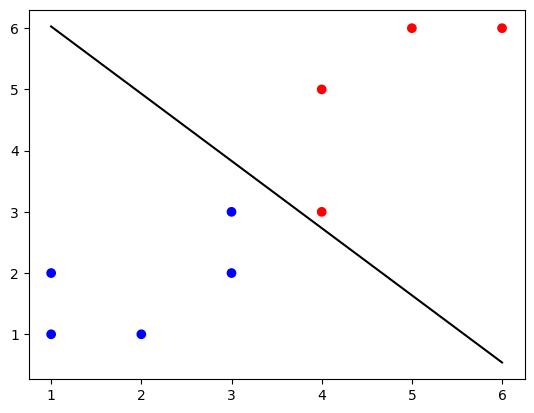

In [31]:
plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c=y_train,
    cmap="bwr"
)

x1 = np.linspace(
    x_train[:,0].min(),
    x_train[:,0].max(),
    100
)

x2 = -(w[0]*x1 + b)/w[1]

plt.plot(x1, x2, 'k-')
plt.show()